In [2]:
import pandas as pd
df = pd.read_csv('Heart.csv')
print("Shape:",df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Shape: (303, 15)

Columns:
 ['Unnamed: 0', 'Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']


,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [3]:
# Dataset Load:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Heart.csv')
df = df.drop('Unnamed: 0', axis=1)
df = df.drop_duplicates()
df = df.dropna()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (297, 14)
Columns: ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD']


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [4]:
# KPIs Define :
# KPI 1: Average Age of patients
kpi1 = df['Age'].mean()
print("KPI 1 - Average Age:", round(kpi1, 2))

# KPI 2: Heart Disease Rate
kpi2 = df['AHD'].value_counts(normalize=True) * 100
print("\nKPI 2 - Heart Disease Rate:")
print(kpi2)

# KPI 3: Average Cholesterol
kpi3 = df['Chol'].mean()
print("\nKPI 3 - Average Cholesterol:", round(kpi3, 2))

# KPI 4: Average Max Heart Rate
kpi4 = df['MaxHR'].mean()
print("\nKPI 4 - Average Max Heart Rate:", round(kpi4, 2))

# KPI 5: Gender Distribution
kpi5 = df['Sex'].value_counts()
print("\nKPI 5 - Gender Distribution:")
print(kpi5)

KPI 1 - Average Age: 54.54

KPI 2 - Heart Disease Rate:
AHD
No     53.872054
Yes    46.127946
Name: proportion, dtype: float64

KPI 3 - Average Cholesterol: 247.35

KPI 4 - Average Max Heart Rate: 149.6

KPI 5 - Gender Distribution:
Sex
1    201
0     96
Name: count, dtype: int64


In [5]:
# Segmentation Analysis :
# Features select karo
features = ['Age', 'RestBP', 'Chol', 'MaxHR']
X = df[features]

# Standardize karo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Risk_Cluster'] = kmeans.fit_predict(X_scaled)

# Risk labels assign karo
cluster_means = df.groupby('Risk_Cluster')['Chol'].mean()
sorted_clusters = cluster_means.sort_values()
risk_map = {
    sorted_clusters.index[0]: 'Low Risk',
    sorted_clusters.index[1]: 'Medium Risk',
    sorted_clusters.index[2]: 'High Risk'
}
df['Risk_Level'] = df['Risk_Cluster'].map(risk_map)

print("Risk Level Distribution:")
print(df['Risk_Level'].value_counts())

Risk Level Distribution:
Risk_Level
Low Risk       131
Medium Risk     92
High Risk       74
Name: count, dtype: int64


C:\Users\zerot\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


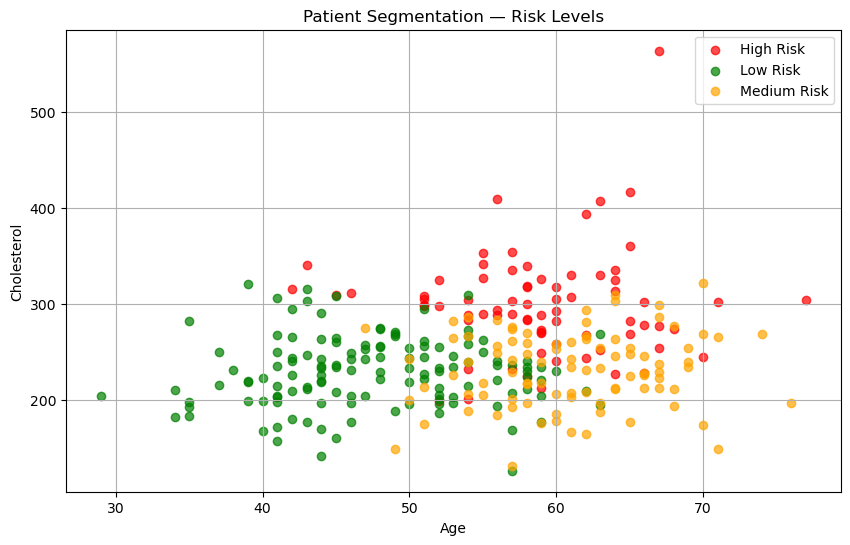

In [6]:
# Cluster Visualization :

plt.figure(figsize=(10,6))
colors = {'Low Risk':'green', 
          'Medium Risk':'orange', 
          'High Risk':'red'}

for risk, group in df.groupby('Risk_Level'):
    plt.scatter(group['Age'],
                group['Chol'],
                label=risk,
                color=colors[risk],
                alpha=0.7)

plt.title('Patient Segmentation — Risk Levels')
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.legend()
plt.grid(True)
plt.show()

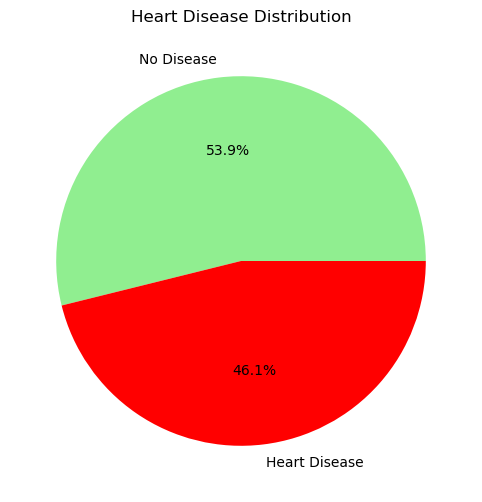

In [7]:
# Heart Disease Distribution :

plt.figure(figsize=(8,6))
df['AHD'].value_counts().plot(kind='pie',
                               autopct='%1.1f%%',
                               colors=['lightgreen','red'],
                               labels=['No Disease','Heart Disease'])
plt.title('Heart Disease Distribution')
plt.ylabel('')
plt.show()

C:\Users\zerot\AppData\Local\Temp\ipykernel_19940\596777534.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AHD', y='Age', data=df,


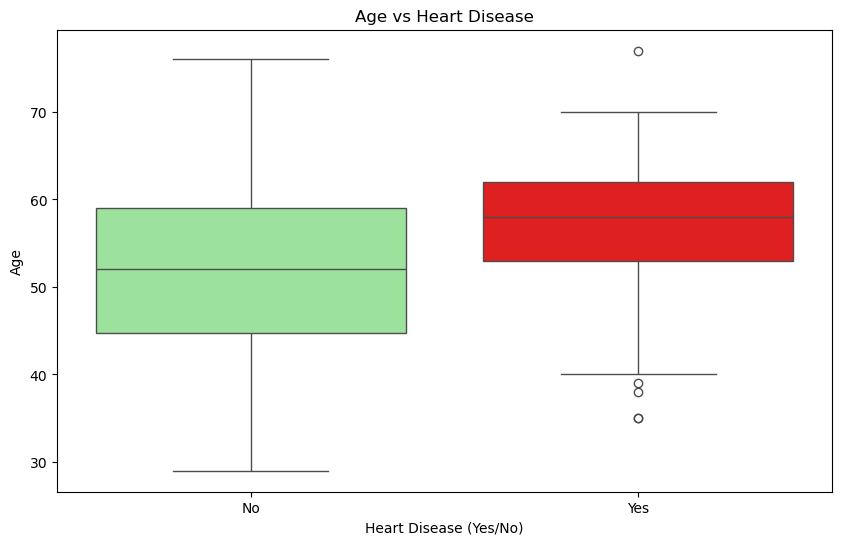

In [8]:
# Age vs Heart Disease :

plt.figure(figsize=(10,6))
sns.boxplot(x='AHD', y='Age', data=df,
            palette={'No':'lightgreen','Yes':'red'})
plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease (Yes/No)')
plt.ylabel('Age')
plt.show()

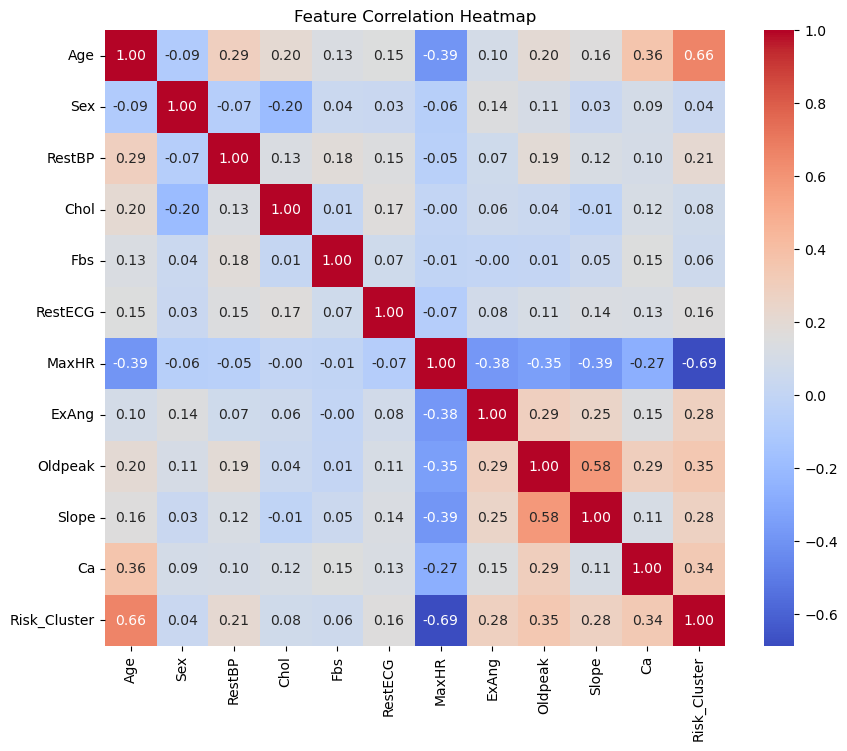

In [9]:
# Correlation Heatmap:

plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

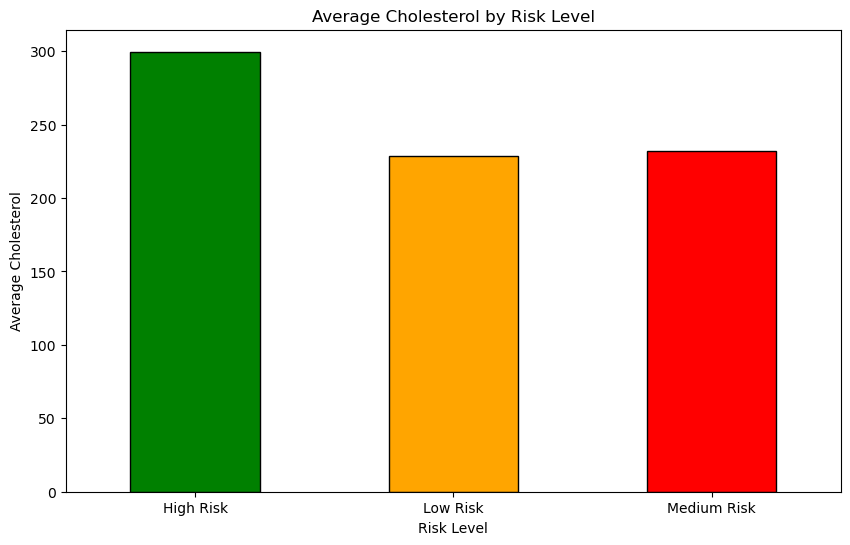

In [10]:
# Cholesterol by Risk Level:

plt.figure(figsize=(10,6))
colors = ['green','orange','red']
df.groupby('Risk_Level')['Chol'].mean().plot(
    kind='bar',
    color=colors,
    edgecolor='black')
plt.title('Average Cholesterol by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Average Cholesterol')
plt.xticks(rotation=0)
plt.show()


In [11]:
# Key Insights:

print("KEY INSIGHTS FROM HEART DISEASE ANALYSIS:")
print("="*45)
print(f"1. Total Patients: {len(df)}")
print(f"2. Average Age: {round(df['Age'].mean(),1)}")
print(f"3. Heart Disease Rate: {round(df['AHD'].value_counts(normalize=True)['Yes']*100,1)}%")
print(f"4. Average Cholesterol: {round(df['Chol'].mean(),1)}")
print(f"5. Average Max Heart Rate: {round(df['MaxHR'].mean(),1)}")
print("6. High Risk patients have highest cholesterol")
print("7. Heart disease more common in older patients")

KEY INSIGHTS FROM HEART DISEASE ANALYSIS:
1. Total Patients: 297
2. Average Age: 54.5
3. Heart Disease Rate: 46.1%
4. Average Cholesterol: 247.4
5. Average Max Heart Rate: 149.6
6. High Risk patients have highest cholesterol
7. Heart disease more common in older patients


In [12]:
# Save Cleaned Dataset:

df.to_csv('heart_cleaned.csv', index=False)
print("Heart cleaned dataset saved successfully!")

Heart cleaned dataset saved successfully!
